# Modelo Propuesto Multimodal: MTDE-Net con Nested CV (Modelo Propuesto)

Este cuaderno implementa el entrenamiento y la evaluación del modelo **Multimodal Thermal Decay Estimation Network (MTDE-Net)** utilizando **Nested Cross-Validation (Validación Cruzada Anidada)** para la estimación del tiempo transcurrido desde el contacto del rastro térmico.

### Características de MTDE-Net:
1. **Rama Visual:** Extrae características de alta resolución espacial mediante bloques residuales combinados con atención dual (espacial y canal, esta última usando Spatial Pyramid Pooling multiescala).
2. **Rama Tabular:** Procesa un vector tabular de 4 dimensiones conteniendo variables ambientales de control (temperatura ambiente y humedad relativa) y variables de superficie (madera/vidrio).
3. **Fusión Tardía (Late Fusion):** Integra las características visuales extraídas por el gap visual (256 dims) con el vector tabular mapeado (64 dims) y pasa por una cabeza de regresión no lineal final.
4. **Validación Cruzada Anidada (Nested CV):** Evalúa el rendimiento de generalización del modelo sintonizando hiperparámetros mediante Optuna en un bucle interno subject-wise (Hold-out), y evaluando en sujetos completamente aislados en el bucle externo.

In [1]:
import sys
import random
import optuna
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# Añadir el directorio raíz al path de Python de forma robusta
current = Path.cwd()
while current.exists() and not (current / "src").exists() and current.parent != current:
    current = current.parent
if (current / "src").exists():
    sys.path.append(str(current))

import torch
from torch.utils.data import DataLoader

from src.loaders import MultimodalThermalDataset
from src.models import MTDE_Net
from src.utils import (
    SqrtScaledMSELoss,
    build_subject_split_plan,
    subject_summary,
    plot_learning_curves,
    plot_prediction_calibration,
    plot_error_by_time_window,
    get_inner_split,
    NCVTracker,
    eval_mtde_net_metrics
)

D:\ulima\Ulima_archivos\UL-2026-1\Seminario1\experimentacion\flir_test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [3]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0003,
    "weight_decay": 0.001,
    "min_time_s": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Partición de Secuencias y Carga de Datasets (Sin Data Leakage)

In [4]:
dev = CONFIG["device"]
metadata_path = "../processed_data/metadata_train.csv"

ds_full = MultimodalThermalDataset(
    metadata_csv=metadata_path,
    is_train=False,
    min_time_s=CONFIG["min_time_s"],
    time_scale=CONFIG["time_scale"]
)
df = ds_full.df

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=9,
    seed=42,
    test_subjects=["tania", "matias"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test Fijo ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects}, Val subjects {f.val_subjects}")

Resumen de sujetos en metadata:
         name  n_sequences  n_samples      surface  gender  is_complete
0      alonso            6        282  glass, wood    male         True
1      angelo            6        281  glass, wood    male         True
2     claudia            6        282  glass, wood  female         True
3     eduardo            1         47         wood    male        False
4     esteban            6        276  glass, wood    male         True
5    fabricio            6        277  glass, wood    male         True
6   juandiego            6        280  glass, wood    male         True
7      matias            6        282  glass, wood    male         True
8     melissa            6        282  glass, wood  female         True
9      renato            6        278  glass, wood    male         True
10      tania            6        278  glass, wood  female         True
11    yohamin            6        276  glass, wood    male         True

Plan de partición:
Sujetos de T

### 4. Inicialización del Modelo, Pérdida y Optimización

In [5]:
model = MTDE_Net().to(dev)
print(f"Modelo MTDE-Net inicializado con {sum(p.numel() for p in model.parameters()):,} parámetros")

Modelo MTDE-Net inicializado con 1,325,421 parámetros


--- 
## 5. Bucle de Validación Cruzada Anidada (Nested Cross-Validation)

En esta sección ejecutamos la validación cruzada anidada de 9 folds (Leave-One-Subject-Out en el bucle externo sobre los sujetos completos disponibles).

Para cada fold externo:
1. Se aíslan los 8 sujetos de entrenamiento y el sujeto de prueba.
2. Se ejecuta una búsqueda de hiperparámetros con **Optuna** (bucle interno, 10 trials) utilizando un split de Hold-out interno (7 sujetos de entrenamiento, 1 sujeto de validación) para optimizar la velocidad.
3. Se entrena el modelo definitivo del fold con los parámetros óptimos y se evalúa sobre el sujeto de prueba externo.
4. Se consolidan las métricas promedio de generalización mediante `NCVTracker`.

In [6]:
INNER_CONFIG = {
    "epochs": 20,
    "patience": 5,
    "n_trials": 10
}

OUTER_CONFIG = {
    "epochs": 50,
    "patience": 10
}

# Inicializar Tracker para NCV y lista de historias
tracker = NCVTracker("MTDE-Net")
histories_base = []
best_params_list = []

print("=" * 60)
print("NESTED CROSS-VALIDATION POR SUJETO (9 FOLDS EXTERNOS) - MTDE-Net")
print("=" * 60)

for fold_idx, fold in enumerate(plan.folds):
    print(f"\n>>> INICIANDO FOLD EXTERNO {fold.fold}/9 <<<")
    print(f"Sujetos de entrenamiento (bucle externo): {fold.train_subjects}")
    print(f"Sujeto de prueba (bucle externo): {fold.val_subjects}")
    
    # 1. Definir la función objetivo de Optuna para el bucle interno
    def objective(trial):
        set_seed(42)
        
        # Espacio de búsqueda de hiperparámetros
        lr = trial.suggest_float("lr", 5e-5, 2e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        
        inner_train_subs, inner_val_subs = get_inner_split(fold.train_subjects, fold_idx)
        
        inner_train_indices = ds_full.df[ds_full.df["name"].isin(inner_train_subs)].index.tolist()
        inner_val_indices = ds_full.df[ds_full.df["name"].isin(inner_val_subs)].index.tolist()
        
        train_ds = MultimodalThermalDataset(
            metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"],
            time_scale=CONFIG["time_scale"], indices=inner_train_indices
        )
        val_ds = MultimodalThermalDataset(
            metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"],
            time_scale=CONFIG["time_scale"], indices=inner_val_indices,
            means=train_ds.means, stds=train_ds.stds
        )
        train_ds.root = Path("../processed_data")
        val_ds.root = Path("../processed_data")
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)
        
        model = MTDE_Net(dropout=dropout).to(dev)
        crit = SqrtScaledMSELoss(scale=None)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        best_val_mae = float("inf")
        no_imp = 0
        
        for ep in range(INNER_CONFIG["epochs"]):
            model.train()
            for x_img, x_tab, y in train_loader:
                x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
                opt.zero_grad(set_to_none=True)
                loss = crit(model(x_img, x_tab), y)
                loss.backward()
                opt.step()
                
            model.eval()
            val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
            v_mae = val_m["mae"]
            
            if v_mae < best_val_mae - 0.5:
                best_val_mae = v_mae
                no_imp = 0
            else:
                no_imp += 1
            if no_imp >= INNER_CONFIG["patience"]:
                break
                
            trial.report(v_mae, step=ep)
            if trial.should_prune():
                raise optuna.TrialPruned()
                
        return best_val_mae

    # 2. Correr la optimización de Optuna en el bucle interno
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=1))
    study.optimize(objective, n_trials=INNER_CONFIG["n_trials"])
    best_params = study.best_params
    best_params_list.append(best_params)
    print(f"Mejores parámetros para Fold {fold.fold}: {best_params}")
    
    # 3. Entrenar el modelo final de este fold externo con los mejores parámetros
    inner_train_subs, inner_val_subs = get_inner_split(fold.train_subjects, fold_idx)
    inner_train_indices = ds_full.df[ds_full.df["name"].isin(inner_train_subs)].index.tolist()
    inner_val_indices = ds_full.df[ds_full.df["name"].isin(inner_val_subs)].index.tolist()
    test_indices = ds_full.df[ds_full.df["name"].isin(fold.val_subjects)].index.tolist()
    
    train_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"],
        time_scale=CONFIG["time_scale"], indices=inner_train_indices
    )
    val_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"],
        time_scale=CONFIG["time_scale"], indices=inner_val_indices,
        means=train_ds.means, stds=train_ds.stds
    )
    test_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"],
        time_scale=CONFIG["time_scale"], indices=test_indices,
        means=train_ds.means, stds=train_ds.stds
    )
    train_ds.root = Path("../processed_data")
    val_ds.root = Path("../processed_data")
    test_ds.root = Path("../processed_data")
    
    train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"])
    test_loader = DataLoader(test_ds, batch_size=best_params["batch_size"])
    
    model = MTDE_Net(dropout=best_params["dropout"]).to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(OUTER_CONFIG["epochs"]):
        model.train()
        train_loss, n = 0.0, 0
        for x_img, x_tab, y in train_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_img, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_img.size(0)
            n += x_img.size(0)
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_img, val_x_tab, val_y in val_loader:
                val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_img, val_x_tab), val_y)
                val_loss += loss.item() * val_x_img.size(0)
                val_n += val_x_img.size(0)
        
        val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
        train_m = eval_mtde_net_metrics(model, train_loader, dev, scale=CONFIG["time_scale"])
        v_mae = val_m["mae"]
        
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss / val_n)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if v_mae < best_val_mae - CONFIG["min_delta"]:
            best_val_mae = v_mae
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= OUTER_CONFIG["patience"]:
            break
            
    if best_state is not None:
        model.load_state_dict(best_state)
    model = model.to(dev)
    model.eval()
    
    test_m = eval_mtde_net_metrics(model, test_loader, dev, scale=CONFIG["time_scale"])
    print(f"Fold {fold.fold} - Test MAE (Sujeto {fold.val_subjects[0]}): {test_m['mae']:.2f}s | RMSE: {test_m['rmse']:.2f}s")
    
    tracker.add_fold_result(fold_idx, best_params, {
        "mae": test_m["mae"],
        "rmse": test_m["rmse"],
        "r2": test_m["r2"],
        "mape": test_m["mape"],
        "acc_60": test_m["acc60"],
        "acc_120": test_m["acc120"]
    })
    histories_base.append(history)

tracker.print_summary()

NESTED CROSS-VALIDATION POR SUJETO (9 FOLDS EXTERNOS) - MTDE-Net

>>> INICIANDO FOLD EXTERNO 1/9 <<<
Sujetos de entrenamiento (bucle externo): ['alonso', 'angelo', 'claudia', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Sujeto de prueba (bucle externo): ['esteban']


Mejores parámetros para Fold 1: {'lr': 0.0011958456312942693, 'weight_decay': 0.0003001352847012186, 'batch_size': 32, 'dropout': 0.24318670936042694}


Fold 1 - Test MAE (Sujeto esteban): 51.84s | RMSE: 60.47s

>>> INICIANDO FOLD EXTERNO 2/9 <<<
Sujetos de entrenamiento (bucle externo): ['angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Sujeto de prueba (bucle externo): ['alonso']


Mejores parámetros para Fold 2: {'lr': 0.000921047806457845, 'weight_decay': 0.003927454062389916, 'batch_size': 64, 'dropout': 0.32632005634868677}


Fold 2 - Test MAE (Sujeto alonso): 62.90s | RMSE: 84.69s

>>> INICIANDO FOLD EXTERNO 3/9 <<<
Sujetos de entrenamiento (bucle externo): ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'yohamin']
Sujeto de prueba (bucle externo): ['renato']


...

Mejores parámetros para Fold 8: {'lr': 0.0006980419092573386, 'weight_decay': 7.829996287723034e-05, 'batch_size': 16, 'dropout': 0.14864245283318317}


Fold 8 - Test MAE (Sujeto juandiego): 28.64s | RMSE: 43.99s

>>> INICIANDO FOLD EXTERNO 9/9 <<<
Sujetos de entrenamiento (bucle externo): ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato']
Sujeto de prueba (bucle externo): ['yohamin']


Mejores parámetros para Fold 9: {'lr': 0.0003363274304478933, 'weight_decay': 0.003448647130329661, 'batch_size': 64, 'dropout': 0.36252723734225456}


Fold 9 - Test MAE (Sujeto yohamin): 40.76s | RMSE: 57.81s

=================== RESULTADOS DE NESTED CV PARA MTDE-NET ===================
|   Fold |      mae |     rmse |       r2 |     mape |   acc_60 |   acc_120 | Mejores Parámetros                                                                                                      |
|-------:|---------:|---------:|---------:|---------:|---------:|----------:|:------------------------------------------------------------------------------------------------------------------------|
|      1 |  51.8373 |  60.4691 | 0.857387 | 116.169  |  72.8261 |   95.6522 | {'lr': 0.0011958456312942693, 'weight_decay': 0.0003001352847012186, 'batch_size': 32, 'dropout': 0.24318670936042694}  |
|      2 |  62.9038 |  84.6858 | 0.736224 |  46.9247 |  59.5745 |   85.461  | {'lr': 0.000921047806457845, 'weight_decay': 0.003927454062389916, 'batch_size': 64, 'dropout': 0.32632005634868677}    |
|      3 |  46.0643 |  69.8809 | 0.810276 |  88.9638 |  78.0576

,Métrica,Media ± Desviación Estándar (Outer CV)
0,MAE,49.65 s ± 24.02 s
1,RMSE,66.04 s ± 24.21 s
2,R2,0.8163 ± 0.1458
3,MAPE,64.24% ± 51.79%
4,ACC_60,70.83% ± 21.12%
5,ACC_120,90.21% ± 10.05%


### 5.5 Consolidación de Hiperparámetros (Mediana y Moda)

Calculamos automáticamente los hiperparámetros definitivos para el entrenamiento final. 
Para evitar sesgos y mantener estabilidad, tomamos la **mediana** para los hiperparámetros continuos (como la tasa de aprendizaje `lr` o el `dropout`) y la **moda** (el valor más común) para los hiperparámetros discretos/categóricos (como `batch_size`, `seq_len` o `lstm_hidden_dim`) obtenidos en los 9 folds del bucle externo.

In [7]:
recommended_params = {}
if 'best_params_list' in locals() and len(best_params_list) > 0:
    for k in best_params_list[0].keys():
        vals = [p[k] for p in best_params_list]
        if all(isinstance(v, float) for v in vals):
            recommended_params[k] = float(np.median(vals))
        else:
            recommended_params[k] = Counter(vals).most_common(1)[0][0]
else:
    # Parámetros por defecto estables (fallbacks si no se corrió el NCV completo)
    recommended_params = {
        "lr": 0.0002,
        "weight_decay": 0.003,
        "batch_size": 16,
        "dropout": 0.22
    }

print("=" * 60)
print("HIPERPARÁMETROS RECOMENDADOS PARA EL MODELO DEFINITIVO:")
print("=" * 60)
for k, v in recommended_params.items():
    print(f"  {k}: {v}")

HIPERPARÁMETROS RECOMENDADOS PARA EL MODELO DEFINITIVO:
  lr: 0.0006980419092573386
  weight_decay: 0.0011061943585965457
  batch_size: 32
  dropout: 0.3143696834659835


--- 
## 6. Modelo Definitivo y Evaluación en el Held-out Test Set

Una vez validada la capacidad de generalización del pipeline mediante Nested CV, entrenamos un modelo definitivo utilizando todos los sujetos disponibles para entrenamiento/validación (`plan.trainval_subjects`) con hiperparámetros estables. 

Finalmente, evaluamos el modelo definitivo en el conjunto de prueba aislado reservado (`test_subjects`: tania, matias y eduardo) para verificar su rendimiento en condiciones del mundo real.

In [8]:
# Entrenamiento del modelo definitivo en todo Train/Val y evaluación en Test Set
final_params = recommended_params

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO PROPUESTO DEFINITIVO EN TODO TRAIN-VAL Y EVAL EN TEST")
print("=" * 60)

trainval_indices = ds_full.df[ds_full.df["name"].isin(plan.trainval_subjects)].index.tolist()
test_indices = ds_full.df[ds_full.df["name"].isin(plan.test_subjects)].index.tolist()

trainval_ds = MultimodalThermalDataset(metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"], indices=trainval_indices)
test_ds = MultimodalThermalDataset(metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"], indices=test_indices, means=trainval_ds.means, stds=trainval_ds.stds)
trainval_ds.root = Path("../processed_data")
test_ds.root = Path("../processed_data")

trainval_loader = DataLoader(trainval_ds, batch_size=final_params["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=final_params["batch_size"])

model_final = MTDE_Net(dropout=final_params["dropout"]).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_final.parameters(), lr=final_params["lr"], weight_decay=final_params["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.8)

epochs = 35
for ep in range(1, epochs + 1):
    model_final.train()
    for x_img, x_tab, y in trainval_loader:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_final(x_img, x_tab), y)
        loss.backward()
        opt.step()
    scheduler.step()

torch.save(model_final.state_dict(), "../MTDE_Net_final.pt")
final_metrics = eval_mtde_net_metrics(model_final, test_loader, dev, scale=CONFIG["time_scale"])
print(f"Modelo Propuesto Final evaluado en Test Set. MAE: {final_metrics['mae']:.2f}s | RMSE: {final_metrics['rmse']:.2f}s | R²: {final_metrics['r2']:.4f}")
print("\nResumen de Resultados para MTDE-Net (Tesis)")
pd.DataFrame({
    "Métrica": [
        "MAE Test (Generalización)",
        "RMSE Test (Generalización)",
        "R² Test (Generalización)",
        "MAPE Test (Error %)",
        "Acc@60s Test",
        "Acc@120s Test"
    ],
    "Valor (Propuesto)": [
        f"{final_metrics['mae']:.2f} s",
        f"{final_metrics['rmse']:.2f} s",
        f"{final_metrics['r2']:.4f}",
        f"{final_metrics['mape']:.2f} %",
        f"{final_metrics['acc60']:.2f} %",
        f"{final_metrics['acc120']:.2f} %"
    ]
})

ENTRENAMIENTO DEL MODELO PROPUESTO DEFINITIVO EN TODO TRAIN-VAL Y EVAL EN TEST


Modelo Propuesto Final evaluado en Test Set. MAE: 42.85s | RMSE: 60.80s | R²: 0.8606

Resumen de Resultados para MTDE-Net (Tesis)


,Métrica,Valor (Propuesto)
0,MAE Test (Generalización),42.85 s
1,RMSE Test (Generalización),60.80 s
2,R² Test (Generalización),0.8606
3,MAPE Test (Error %),30.77 %
4,Acc@60s Test,75.62 %
5,Acc@120s Test,91.60 %


--- 
## 7. Visualización de Resultados y Curvas de Aprendizaje

Generamos las curvas de aprendizaje del último fold de NCV para verificar la estabilidad de la optimización. Adicionalmente, graficamos la calibración de las predicciones y la distribución de error por ventana temporal sobre el Held-out Test Set.

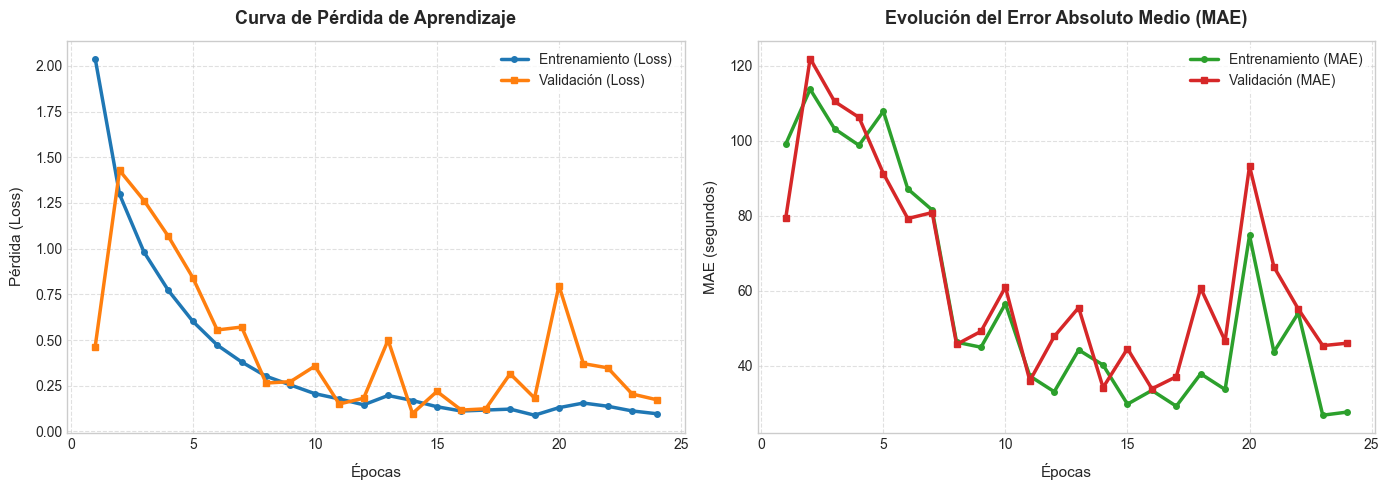

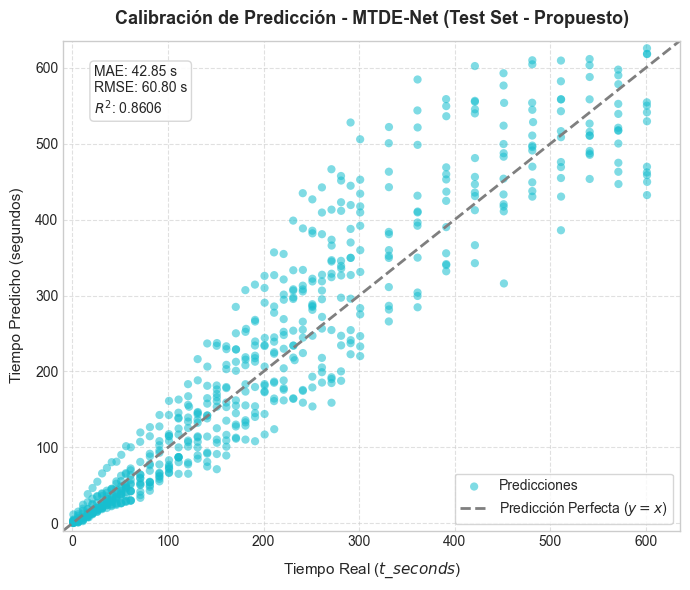

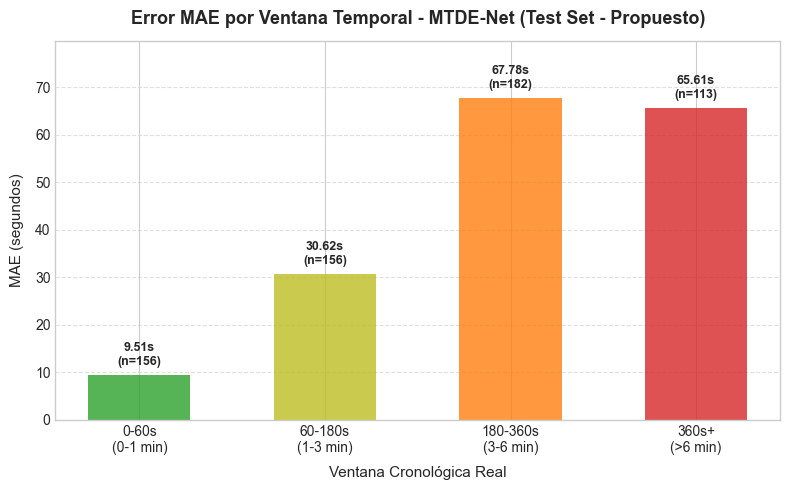

In [9]:
# Cargar el modelo final entrenado para graficar y evaluar predicciones en Test
model_final.load_state_dict(torch.load("../MTDE_Net_final.pt"))
model_final.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x_img, x_tab, y in test_loader:
        x_img, x_tab = x_img.to(dev), x_tab.to(dev)
        pred = model_final(x_img, x_tab)
        # Multiplicar por scale=30.0 para evaluar en segundos reales
        y_true.extend((y * CONFIG["time_scale"]).numpy().tolist())
        y_pred.extend((pred * CONFIG["time_scale"]).cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Curvas de aprendizaje del último fold de validación cruzada anidada
plot_learning_curves(histories_base[-1])

# 2. Curva de Calibración
plot_prediction_calibration(y_true, y_pred, model_name="MTDE-Net (Test Set - Propuesto)")

# 3. Gráfico de Error por Ventana de Tiempo
plot_error_by_time_window(y_true, y_pred, model_name="MTDE-Net (Test Set - Propuesto)")